In [2]:
import os
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")

In [4]:
DATA_DIR = "/Users/ameer/Cellula/MI CSV"
LABELS_FILE = "/Users/ameer/Cellula/labels.csv"

In [ ]:
csv_files = glob.glob(
    os.path.join(DATA_DIR, "cellula_MI_data_*.csv")
)
csv_files = sorted(
    csv_files,
    key=lambda x: int(
        os.path.basename(x)
        .split("_")[-1]
        .replace(".csv", "")
    )
)
print("Number of EEG files:", len(csv_files))

print("\nFirst 10 files:")
for file in csv_files[:10]:
    print(os.path.basename(file))

Number of EEG files: 2160

First 10 files:
cellula_MI_data_1.csv
cellula_MI_data_2.csv
cellula_MI_data_3.csv
cellula_MI_data_4.csv
cellula_MI_data_5.csv
cellula_MI_data_6.csv
cellula_MI_data_7.csv
cellula_MI_data_8.csv
cellula_MI_data_9.csv
cellula_MI_data_10.csv


In [6]:
labels_df = pd.read_csv(LABELS_FILE)

print("Labels shape:", labels_df.shape)

print("\nColumns:")
print(labels_df.columns.tolist())

display(labels_df.head())

Labels shape: (2400, 1)

Columns:
['label']


,label
0,Left
1,Right
2,Left
3,Left
4,Left


In [ ]:
print("Labels columns:")
print(labels_df.columns.tolist())
possible_label_columns = [
    "label",
    "Label",
    "LABEL",
    "class",
    "Class",
    "CLASS"
]

LABEL_COLUMN = None

for col in possible_label_columns:
    if col in labels_df.columns:
        LABEL_COLUMN = col
        break

# If no standard name is found, use the last column
if LABEL_COLUMN is None:
    LABEL_COLUMN = labels_df.columns[-1]

print("\nUsing label column:", LABEL_COLUMN)

# Clean labels
labels_df[LABEL_COLUMN] = (
    labels_df[LABEL_COLUMN]
    .astype(str)
    .str.strip()
    .str.title()
)

# Number of files and labels
n_files = len(csv_files)
n_labels = len(labels_df)

print("\nEEG files :", n_files)
print("Labels    :", n_labels)

# Number of pairs that can be mapped
n = min(n_files, n_labels)

# Create mapping
mapping_df = pd.DataFrame({
    "file": [
        os.path.basename(f)
        for f in csv_files[:n]
    ],

    "file_number": [
        int(
            os.path.basename(f)
            .split("_")[-1]
            .replace(".csv", "")
        )
        for f in csv_files[:n]
    ],

    "label": labels_df.iloc[:n][LABEL_COLUMN].values
})

print("\nMapping created successfully!")

display(mapping_df.head(10))

Labels columns:
['label']

Using label column: label

EEG files : 2160
Labels    : 2400

Mapping created successfully!


,file,file_number,label
0,cellula_MI_data_1.csv,1,Left
1,cellula_MI_data_2.csv,2,Right
2,cellula_MI_data_3.csv,3,Left
3,cellula_MI_data_4.csv,4,Left
4,cellula_MI_data_5.csv,5,Left
5,cellula_MI_data_6.csv,6,Right
6,cellula_MI_data_7.csv,7,Right
7,cellula_MI_data_8.csv,8,Left
8,cellula_MI_data_9.csv,9,Left
9,cellula_MI_data_10.csv,10,Right


Class Distribution:


label
Left     1082
Right    1078
Name: count, dtype: int64

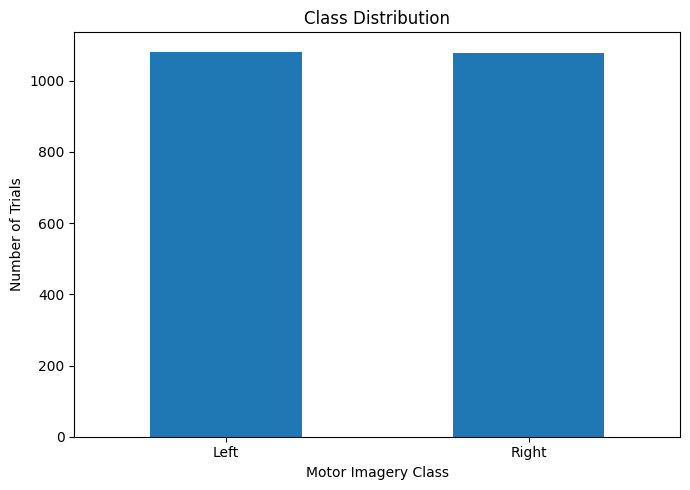

In [ ]:
class_counts = mapping_df["label"].value_counts()

print("Class Distribution:")
display(class_counts)

# Plot
plt.figure(figsize=(7, 5))

class_counts.plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Motor Imagery Class")
plt.ylabel("Number of Trials")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
time_info = []

for file in csv_files:

    df = pd.read_csv(file)

    time = pd.to_numeric(
        df["Time"],
        errors="coerce"
    ).dropna().values

    dt = np.diff(time)

    positive_dt = dt[dt > 0]

    time_info.append({

        "file": os.path.basename(file),

        "duration_sec":
            time[-1] - time[0],

        "median_dt":
            np.median(positive_dt),

        "min_dt":
            np.min(positive_dt),

        "max_dt":
            np.max(positive_dt),

        "implied_fs":
            1 / np.median(positive_dt)

    })

time_df = pd.DataFrame(time_info)

display(time_df.head())

,file,duration_sec,median_dt,min_dt,max_dt,implied_fs
0,cellula_MI_data_1.csv,9.995046,0.002403,1.999870e-07,0.153939,416.059913
1,cellula_MI_data_2.csv,9.993729,0.002493,2.000001e-06,0.072636,401.090966
2,cellula_MI_data_3.csv,9.992026,0.002473,1.199995e-06,0.084939,404.334465
3,cellula_MI_data_4.csv,10.029750,0.002413,2.000015e-07,0.178850,414.456232
4,cellula_MI_data_5.csv,10.003483,0.002476,5.999900e-07,0.087548,403.844601


In [12]:
print("Trial Duration Statistics")

display(
    time_df["duration_sec"].describe()
)

Trial Duration Statistics


count    2160.000000
mean        9.985076
std         0.119418
min         8.733881
25%         9.975797
50%         9.985092
75%         9.995315
max        11.479649
Name: duration_sec, dtype: float64

In [ ]:
channels = ["FZ", "C3", "CZ", "C4"]

channel_stats = []

for file in csv_files:

    df = pd.read_csv(file)

    for channel in channels:

        x = pd.to_numeric(
            df[channel],
            errors="coerce"
        ).dropna()

        channel_stats.append({

            "file":
                os.path.basename(file),

            "channel":
                channel,

            "mean":
                x.mean(),

            "std":
                x.std(),

            "variance":
                x.var(),

            "min":
                x.min(),

            "max":
                x.max(),

            "range":
                x.max() - x.min()

        })


# Convert results to DataFrame
channel_stats_df = pd.DataFrame(
    channel_stats
)

print("Channel statistics calculated successfully.")

display(
    channel_stats_df.head(10)
)

Channel statistics calculated successfully.


,file,channel,mean,std,variance,min,max,range
0,cellula_MI_data_1.csv,FZ,324770.376525,182.365338,33257.116572,324489.78125,325086.75000,596.96875
1,cellula_MI_data_1.csv,C3,320966.199350,181.396794,32904.797054,320697.84375,321280.68750,582.84375
2,cellula_MI_data_1.csv,CZ,334986.259500,281.435985,79206.213391,334553.15625,335460.71875,907.56250
3,cellula_MI_data_1.csv,C4,320801.713538,428.541342,183647.681429,320128.68750,321480.06250,1351.37500
4,cellula_MI_data_2.csv,FZ,324826.075063,157.632118,24847.884564,324489.93750,325136.00000,646.06250
5,cellula_MI_data_2.csv,C3,321048.736375,256.826050,65959.620073,320027.65625,322035.09375,2007.43750
6,cellula_MI_data_2.csv,CZ,335001.933150,599.972254,359966.705220,332451.90625,337171.87500,4719.96875
7,cellula_MI_data_2.csv,C4,320838.604363,794.004303,630442.833882,317071.84375,323458.62500,6386.78125
8,cellula_MI_data_3.csv,FZ,324892.631650,162.111055,26279.994227,324606.18750,325161.65625,555.46875
9,cellula_MI_data_3.csv,C3,321150.747887,165.839108,27502.609669,320797.00000,321455.12500,658.12500


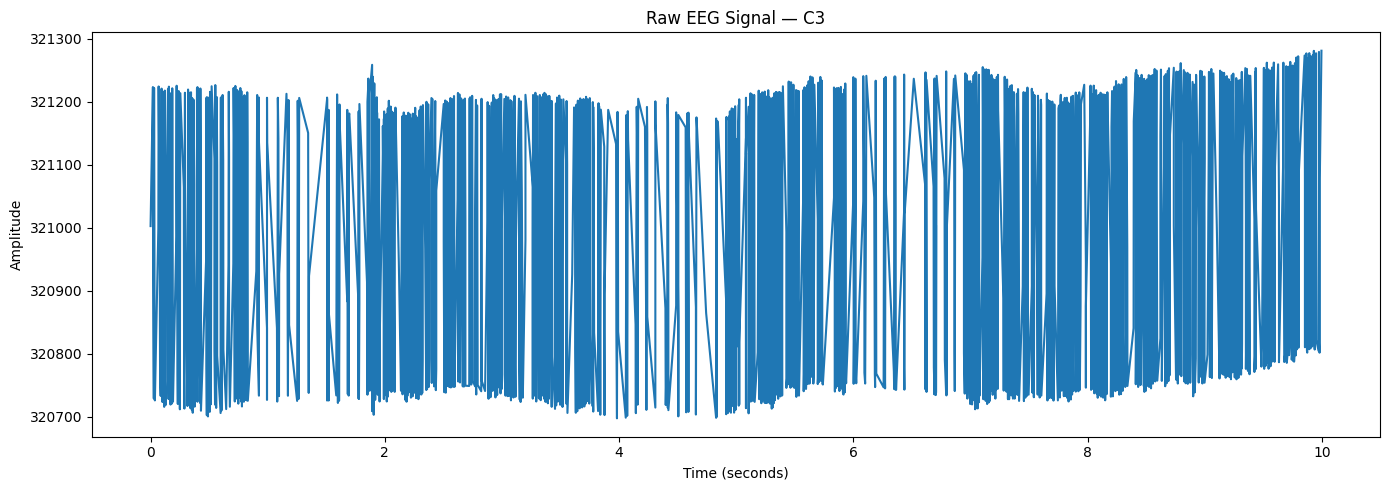

In [17]:
df = pd.read_csv(csv_files[0])

plt.figure(figsize=(14, 5))

time = df["Time"] - df["Time"].iloc[0]

plt.plot(
    time,
    df["C3"]
)

plt.title("Raw EEG Signal — C3")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [18]:
left_file = mapping_df[
    mapping_df["label"] == "Left"
]["file"].iloc[0]

right_file = mapping_df[
    mapping_df["label"] == "Right"
]["file"].iloc[0]

print("Left file :", left_file)
print("Right file:", right_file)

Left file : cellula_MI_data_1.csv
Right file: cellula_MI_data_2.csv


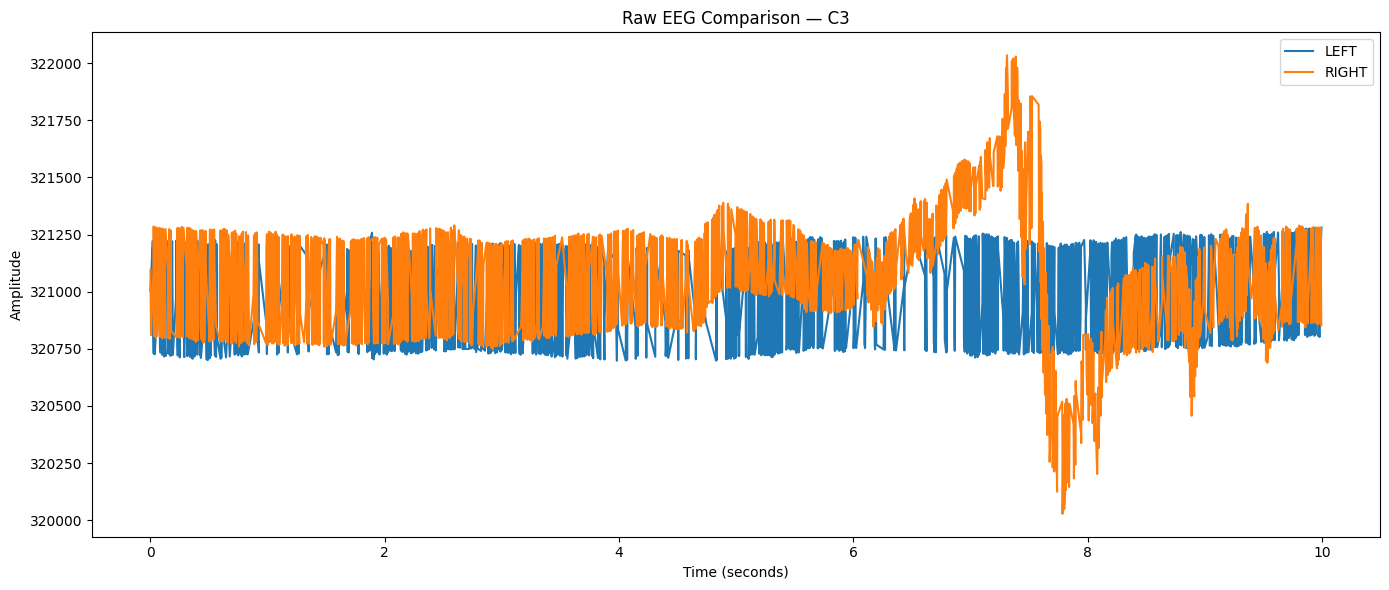

In [19]:
left_df = pd.read_csv(
    os.path.join(DATA_DIR, left_file)
)

right_df = pd.read_csv(
    os.path.join(DATA_DIR, right_file)
)

plt.figure(figsize=(14, 6))

left_time = (
    left_df["Time"] -
    left_df["Time"].iloc[0]
)

right_time = (
    right_df["Time"] -
    right_df["Time"].iloc[0]
)

plt.plot(
    left_time,
    left_df["C3"],
    label="LEFT"
)

plt.plot(
    right_time,
    right_df["C3"],
    label="RIGHT"
)

plt.title(
    "Raw EEG Comparison — C3"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.legend()

plt.tight_layout()
plt.show()

In [20]:
FS = 400

In [21]:
def resample_eeg(df, channel, fs=FS):

    time = pd.to_numeric(
        df["Time"],
        errors="coerce"
    ).values

    x = pd.to_numeric(
        df[channel],
        errors="coerce"
    ).values

    valid = (
        np.isfinite(time) &
        np.isfinite(x)
    )

    time = time[valid]
    x = x[valid]

    # remove duplicated/non-increasing timestamps
    keep = np.r_[
        True,
        np.diff(time) > 0
    ]

    time = time[keep]
    x = x[keep]

    new_time = np.arange(
        time[0],
        time[-1],
        1 / fs
    )

    new_x = np.interp(
        new_time,
        time,
        x
    )

    return new_time, new_x

In [22]:
def detrend_signal(x):

    return signal.detrend(
        np.asarray(x)
    )

Notch filter

In [23]:
def notch_filter(
    x,
    fs=FS,
    frequency=50
):

    b, a = signal.iirnotch(
        frequency,
        Q=30,
        fs=fs
    )

    return signal.filtfilt(
        b,
        a,
        x
    )

In [24]:
def bandpass_filter(
    x,
    fs=FS,
    low=0.5,
    high=40
):

    b, a = signal.butter(
        4,
        [low, high],
        btype="bandpass",
        fs=fs
    )

    return signal.filtfilt(
        b,
        a,
        x
    )

In [25]:
def preprocess_eeg(
    x,
    fs=FS
):

    # Remove trend / DC component
    x = detrend_signal(x)

    # Remove 50 Hz power-line interference
    x = notch_filter(
        x,
        fs=fs,
        frequency=50
    )

    # Band-pass
    x = bandpass_filter(
        x,
        fs=fs,
        low=0.5,
        high=40
    )

    return x

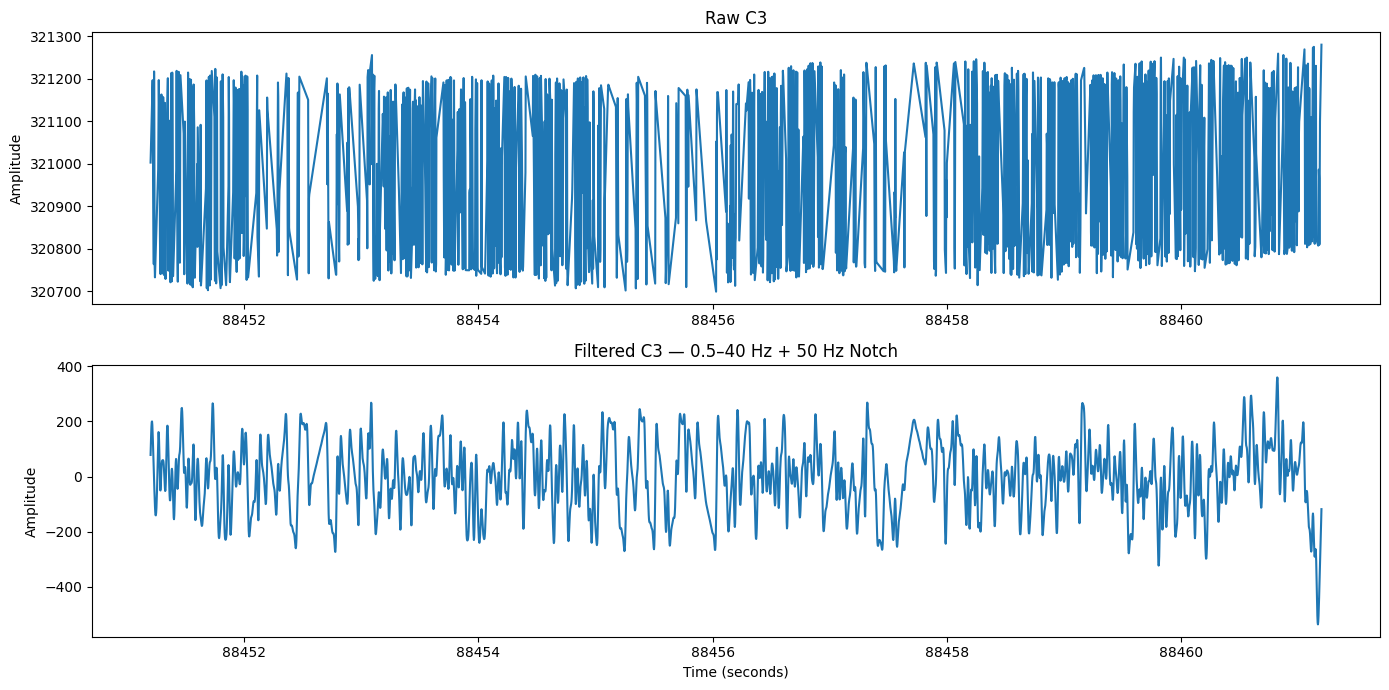

In [26]:
time_uniform, raw_c3 = resample_eeg(
    left_df,
    "C3"
)

filtered_c3 = preprocess_eeg(
    raw_c3
)

plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time_uniform,
    raw_c3
)

plt.title("Raw C3")
plt.ylabel("Amplitude")


plt.subplot(2, 1, 2)

plt.plot(
    time_uniform,
    filtered_c3
)

plt.title(
    "Filtered C3 — 0.5–40 Hz + 50 Hz Notch"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [27]:
def compute_psd(
    x,
    fs=FS
):

    x = detrend_signal(x)

    frequencies, power = signal.welch(
        x,
        fs=fs,
        nperseg=min(
            1024,
            len(x)
        )
    )

    return frequencies, power

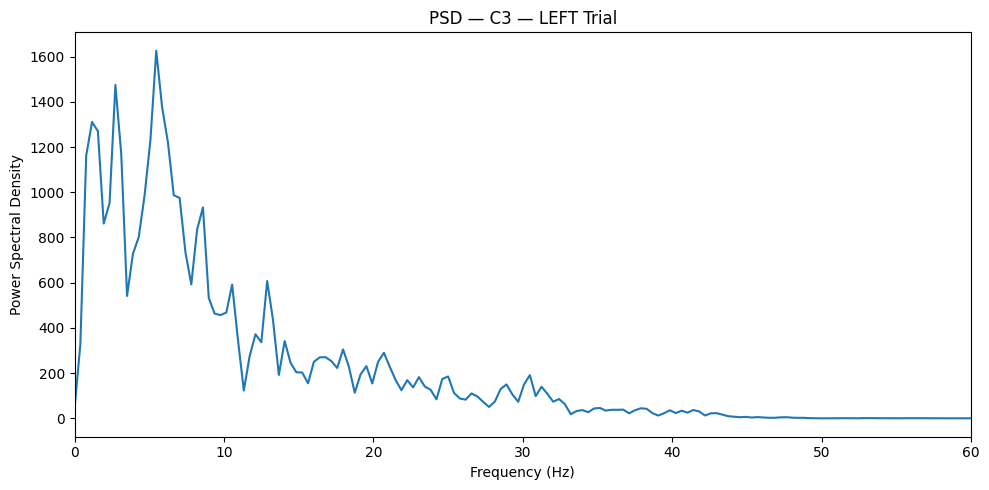

In [28]:
time_uniform, x = resample_eeg(
    left_df,
    "C3"
)

x = preprocess_eeg(x)

frequencies, psd = compute_psd(
    x
)

plt.figure(figsize=(10, 5))

plt.plot(
    frequencies,
    psd
)

plt.xlim(0, 60)

plt.title(
    "PSD — C3 — LEFT Trial"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")

plt.tight_layout()
plt.show()

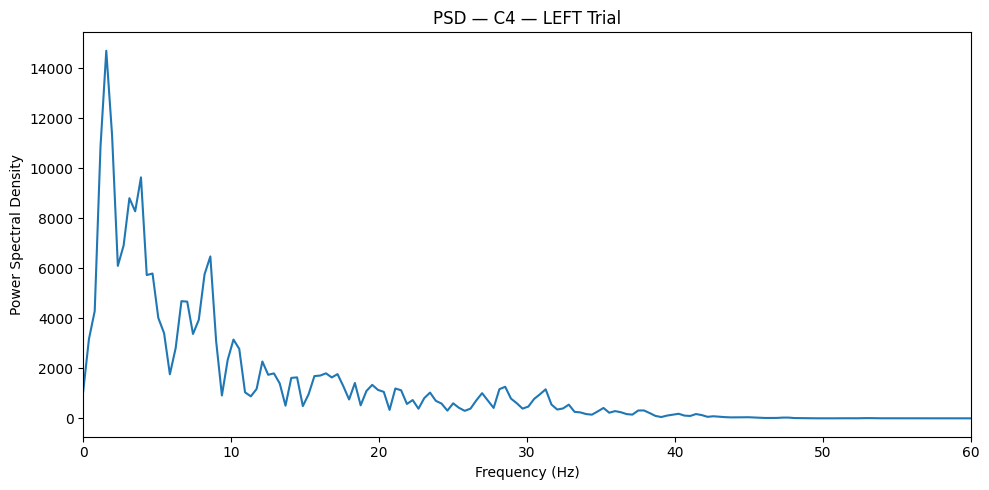

In [29]:
time_uniform, x = resample_eeg(
    left_df,
    "C4"
)

x = preprocess_eeg(x)

frequencies, psd = compute_psd(
    x
)

plt.figure(figsize=(10, 5))

plt.plot(
    frequencies,
    psd
)

plt.xlim(0, 60)

plt.title(
    "PSD — C4 — LEFT Trial"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")

plt.tight_layout()
plt.show()

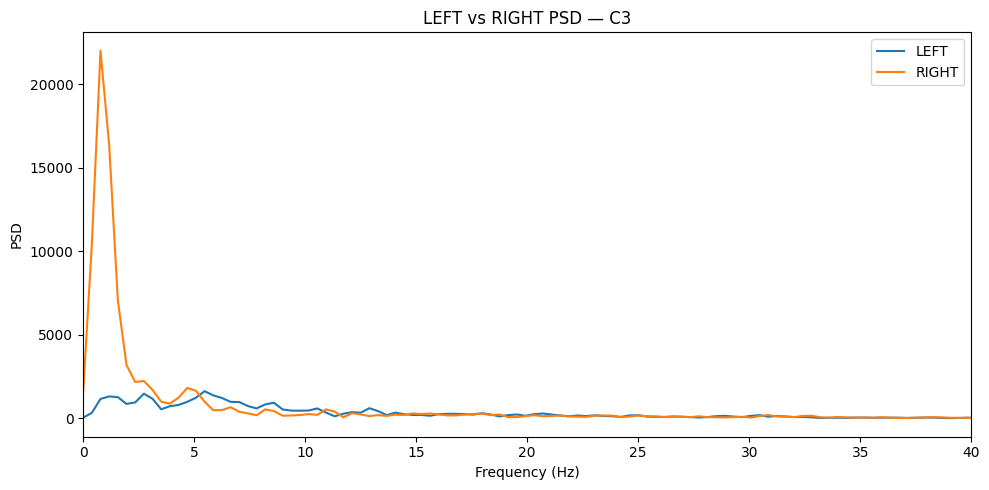

In [30]:
_, left_c3 = resample_eeg(
    left_df,
    "C3"
)

_, right_c3 = resample_eeg(
    right_df,
    "C3"
)

left_c3 = preprocess_eeg(left_c3)
right_c3 = preprocess_eeg(right_c3)

f_left, p_left = compute_psd(left_c3)
f_right, p_right = compute_psd(right_c3)

plt.figure(figsize=(10, 5))

plt.plot(
    f_left,
    p_left,
    label="LEFT"
)

plt.plot(
    f_right,
    p_right,
    label="RIGHT"
)

plt.xlim(0, 40)

plt.title(
    "LEFT vs RIGHT PSD — C3"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")

plt.legend()

plt.tight_layout()
plt.show()

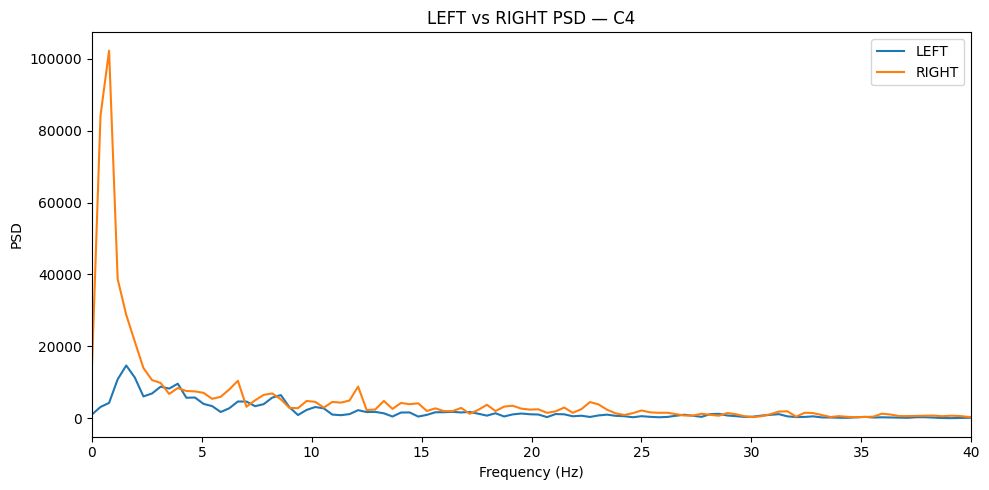

In [31]:
_, left_c4 = resample_eeg(
    left_df,
    "C4"
)

_, right_c4 = resample_eeg(
    right_df,
    "C4"
)

left_c4 = preprocess_eeg(left_c4)
right_c4 = preprocess_eeg(right_c4)

f_left, p_left = compute_psd(left_c4)
f_right, p_right = compute_psd(right_c4)

plt.figure(figsize=(10, 5))

plt.plot(
    f_left,
    p_left,
    label="LEFT"
)

plt.plot(
    f_right,
    p_right,
    label="RIGHT"
)

plt.xlim(0, 40)

plt.title(
    "LEFT vs RIGHT PSD — C4"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")

plt.legend()

plt.tight_layout()
plt.show()

In [32]:
def calculate_band_power(
    frequencies,
    psd,
    low,
    high
):

    mask = (
        (frequencies >= low) &
        (frequencies <= high)
    )

    return np.trapezoid(
        psd[mask],
        frequencies[mask]
    )

In [33]:
mu_power_c3_left = calculate_band_power(
    f_left,
    p_left,
    8,
    12
)

print(
    "Mu Power:",
    mu_power_c3_left
)

Mu Power: 9424.136315358814


In [34]:
beta_power_c3_left = calculate_band_power(
    f_left,
    p_left,
    13,
    30
)

print(
    "Beta Power:",
    beta_power_c3_left
)

Beta Power: 15416.73310469204


In [35]:
band_results = []

for i, file in enumerate(csv_files):

    if i >= len(labels_df):
        break

    label = labels_df.iloc[i][LABEL_COLUMN]

    df = pd.read_csv(file)

    for channel in ["C3", "C4"]:

        _, x = resample_eeg(
            df,
            channel
        )

        x = preprocess_eeg(x)

        f, p = compute_psd(x)

        mu = calculate_band_power(
            f,
            p,
            8,
            12
        )

        beta = calculate_band_power(
            f,
            p,
            13,
            30
        )

        band_results.append({

            "file":
                os.path.basename(file),

            "label":
                label,

            "channel":
                channel,

            "mu_power":
                mu,

            "beta_power":
                beta
        })

band_power_df = pd.DataFrame(
    band_results
)

display(
    band_power_df.head()
)

,file,label,channel,mu_power,beta_power
0,cellula_MI_data_1.csv,Left,C3,1745.552291,2898.584816
1,cellula_MI_data_1.csv,Left,C4,9424.136315,15416.733105
2,cellula_MI_data_2.csv,Right,C3,1037.851571,2468.245533
3,cellula_MI_data_2.csv,Right,C4,14970.886589,36597.898987
4,cellula_MI_data_3.csv,Left,C3,1349.044503,2859.794818


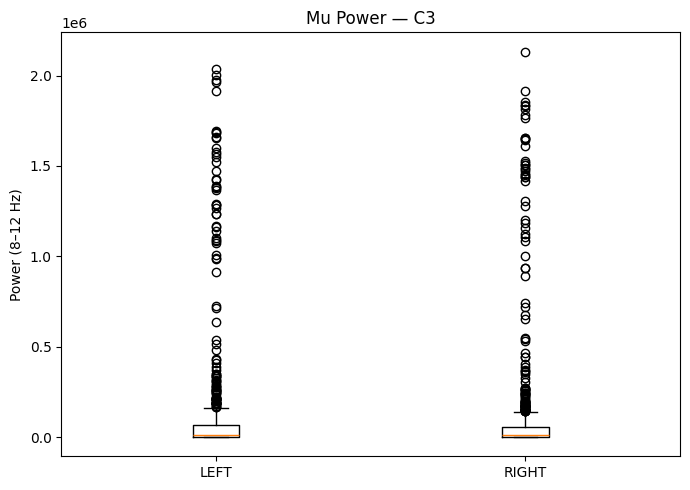

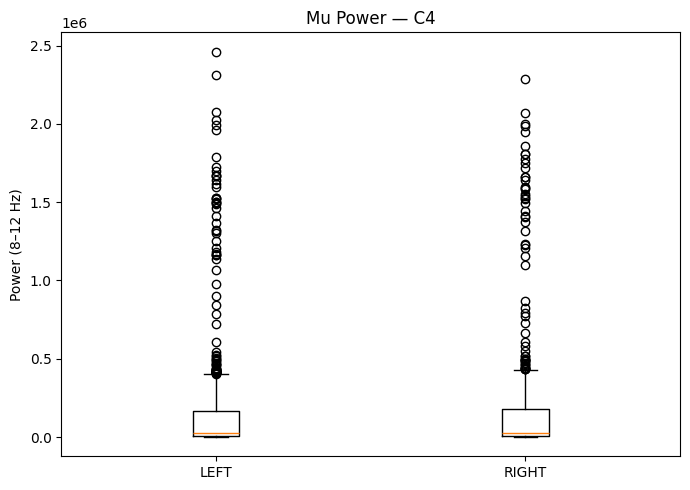

In [36]:
for channel in ["C3", "C4"]:

    data = band_power_df[
        band_power_df["channel"] == channel
    ]

    left = data[
        data["label"] == "Left"
    ]["mu_power"]

    right = data[
        data["label"] == "Right"
    ]["mu_power"]

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [left, right],
        labels=["LEFT", "RIGHT"]
    )

    plt.title(
        f"Mu Power — {channel}"
    )

    plt.ylabel(
        "Power (8–12 Hz)"
    )

    plt.tight_layout()
    plt.show()

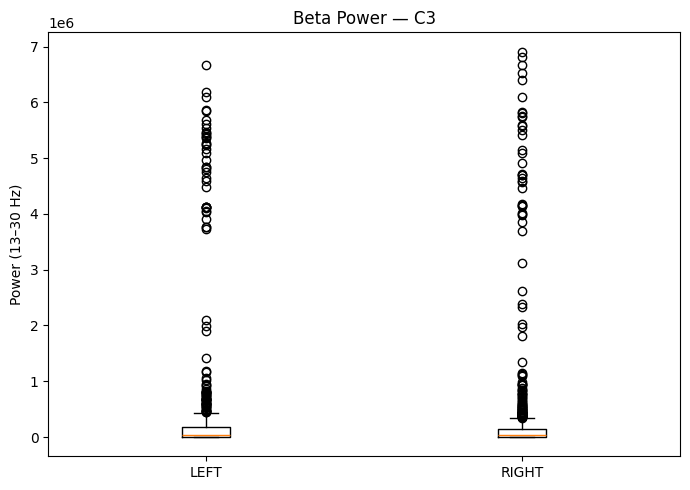

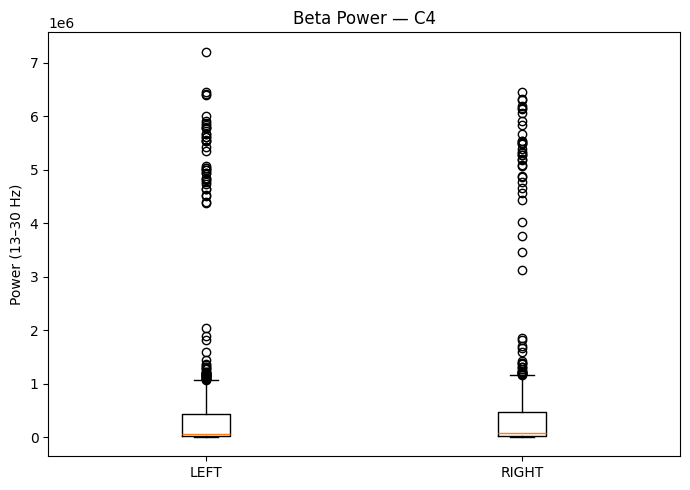

In [37]:
for channel in ["C3", "C4"]:

    data = band_power_df[
        band_power_df["channel"] == channel
    ]

    left = data[
        data["label"] == "Left"
    ]["beta_power"]

    right = data[
        data["label"] == "Right"
    ]["beta_power"]

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [left, right],
        labels=["LEFT", "RIGHT"]
    )

    plt.title(
        f"Beta Power — {channel}"
    )

    plt.ylabel(
        "Power (13–30 Hz)"
    )

    plt.tight_layout()
    plt.show()

In [38]:
statistical_results = []

for channel in ["C3", "C4"]:

    for band in ["mu_power", "beta_power"]:

        data = band_power_df[
            band_power_df["channel"] == channel
        ]

        left = data[
            data["label"] == "Left"
        ][band]

        right = data[
            data["label"] == "Right"
        ][band]

        statistic, p_value = mannwhitneyu(
            left,
            right,
            alternative="two-sided"
        )

        statistical_results.append({

            "channel":
                channel,

            "band":
                band,

            "U":
                statistic,

            "p_value":
                p_value
        })

stats_df = pd.DataFrame(
    statistical_results
)

display(stats_df)

,channel,band,U,p_value
0,C3,mu_power,600633.0,0.228993
1,C3,beta_power,596763.0,0.349309
2,C4,mu_power,583660.0,0.974597
3,C4,beta_power,578587.0,0.750395


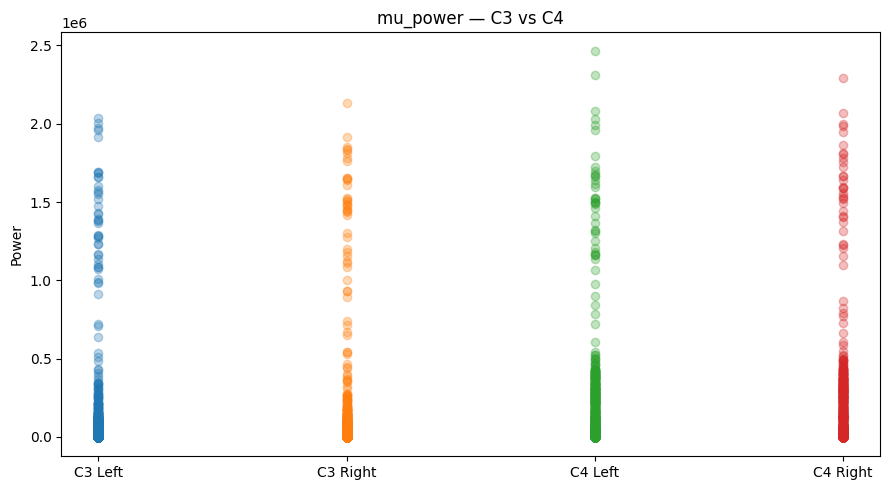

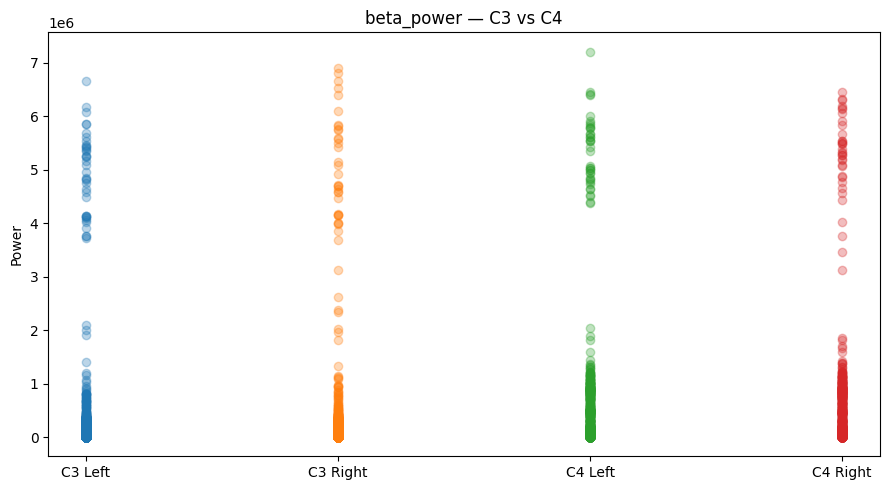

In [39]:
for band in ["mu_power", "beta_power"]:

    plt.figure(figsize=(9, 5))

    for channel in ["C3", "C4"]:

        data = band_power_df[
            band_power_df["channel"] == channel
        ]

        values_left = data[
            data["label"] == "Left"
        ][band]

        values_right = data[
            data["label"] == "Right"
        ][band]

        plt.scatter(
            np.ones(len(values_left)) *
            (1 if channel == "C3" else 3),
            values_left,
            alpha=0.3
        )

        plt.scatter(
            np.ones(len(values_right)) *
            (2 if channel == "C3" else 4),
            values_right,
            alpha=0.3
        )

    plt.xticks(
        [1, 2, 3, 4],
        [
            "C3 Left",
            "C3 Right",
            "C4 Left",
            "C4 Right"
        ]
    )

    plt.title(
        f"{band} — C3 vs C4"
    )

    plt.ylabel("Power")

    plt.tight_layout()
    plt.show()

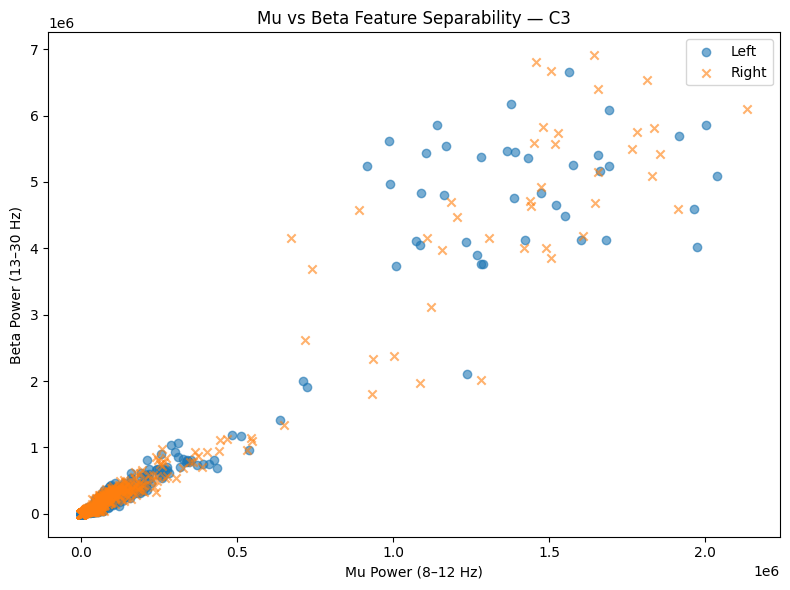

In [40]:
plt.figure(figsize=(8, 6))

for label, marker in [
    ("Left", "o"),
    ("Right", "x")
]:

    data = band_power_df[
        band_power_df["label"] == label
    ]

    c3 = data[
        data["channel"] == "C3"
    ]

    plt.scatter(
        c3["mu_power"],
        c3["beta_power"],
        label=label,
        marker=marker,
        alpha=0.6
    )

plt.title(
    "Mu vs Beta Feature Separability — C3"
)

plt.xlabel(
    "Mu Power (8–12 Hz)"
)

plt.ylabel(
    "Beta Power (13–30 Hz)"
)

plt.legend()

plt.tight_layout()
plt.show()